In [1]:
from google.colab import files
uploaded = files.upload()

Saving dataset -P657 (1).xlsx to dataset -P657 (1).xlsx


In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
from collections import Counter
from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [3]:
# Load Dataset
df = pd.read_excel("dataset -P657 (1).xlsx")

In [4]:
# Check dataset size (rows, columns)
print("Shape of dataset:", df.shape)

# View first few records
df.head()

# Check data types and missing values
df.info()

# Check statistical summary of numeric columns
df.describe()

Shape of dataset: (1440, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   1440 non-null   object
 1   rating  1440 non-null   int64 
 2   body    1440 non-null   object
dtypes: int64(1), object(2)
memory usage: 33.9+ KB


,rating
count,1440.000000
mean,3.173611
std,1.584453
min,1.000000
25%,1.000000
50%,4.000000
75%,5.000000
max,5.000000


In [5]:
# Check missing values in dataset
print(df.isnull().sum())

title     0
rating    0
body      0
dtype: int64


In [6]:
# Drop missing values
df = df.dropna()

In [7]:
# Remove Duplicates
df = df.drop_duplicates()
print("Shape after cleaning:", df.shape)

Shape after cleaning: (1440, 3)


In [8]:
# Combine Text Columns
df['review'] = df['title'] + " " + df['body']

In [9]:
# Create Sentiment Column
def sentiment_label(rating):
    if rating >= 4:
        return "Positive"
    elif rating == 3:
        return "Neutral"
    else:
        return "Negative"

df['sentiment'] = df['rating'].apply(sentiment_label)

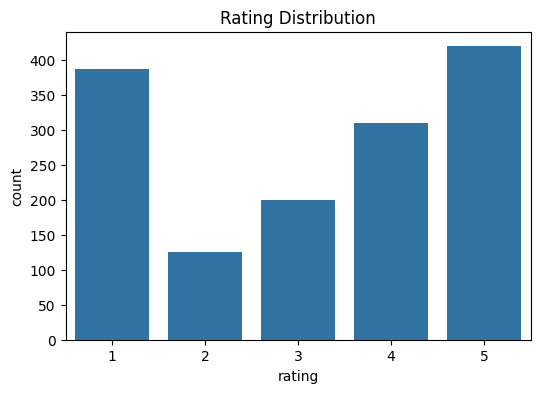

In [10]:
# Rating Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='rating', data=df)
plt.title("Rating Distribution")
plt.show()

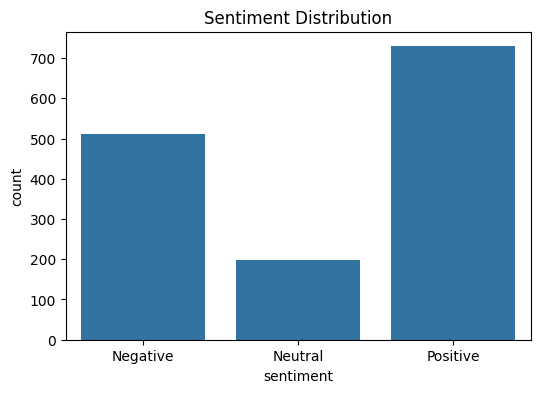

In [11]:
# Sentiment Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='sentiment', data=df)
plt.title("Sentiment Distribution")
plt.show()

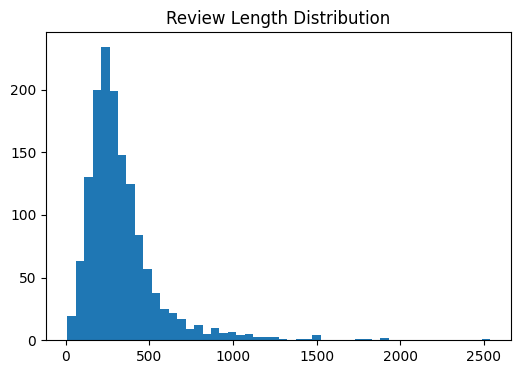

In [12]:
# Review Length Analysis
df['review_length'] = df['review'].apply(len)

plt.figure(figsize=(6,4))
plt.hist(df['review_length'], bins=50)
plt.title("Review Length Distribution")
plt.show()

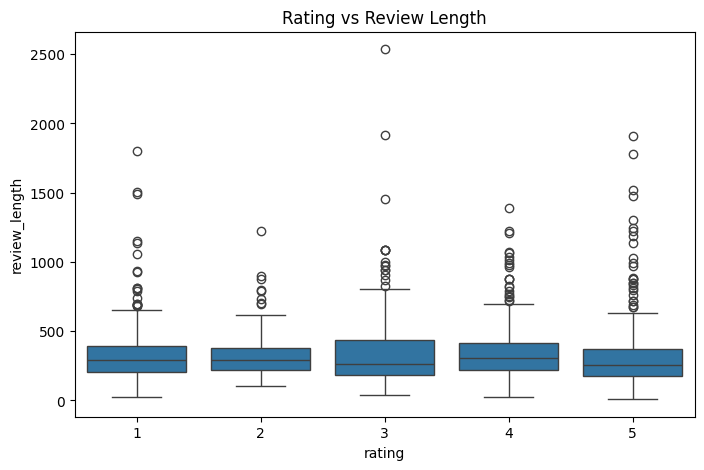

In [13]:
# Rating vs Review Length
plt.figure(figsize=(8,5))
sns.boxplot(x='rating', y='review_length', data=df)
plt.title("Rating vs Review Length")
plt.show()

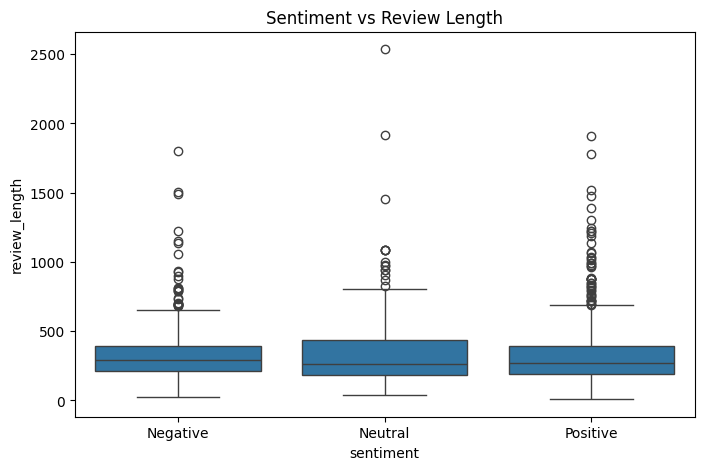

In [14]:
# Sentiment vs Review Length
plt.figure(figsize=(8,5))
sns.boxplot(x='sentiment', y='review_length', data=df)
plt.title("Sentiment vs Review Length")
plt.show()

In [15]:
# Text Processing for EDA
text = " ".join(df['review'])

words = re.findall(r'\w+', text.lower())

# Remove stopwords
stop_words = set(stopwords.words('english'))
filtered_words = [w for w in words if w not in stop_words]

In [16]:
# Top Common Words
common_words = Counter(filtered_words).most_common(20)
print("Top 20 Common Words:")
print(common_words)

Top 20 Common Words:
[('phone', 1879), ('good', 1477), ('camera', 1074), ('battery', 891), ('samsung', 805), ('quality', 719), ('mobile', 619), ('price', 457), ('product', 432), ('buy', 345), ('display', 325), ('also', 322), ('life', 316), ('like', 289), ('2', 285), ('screen', 270), ('use', 269), ('one', 265), ('best', 264), ('better', 263)]


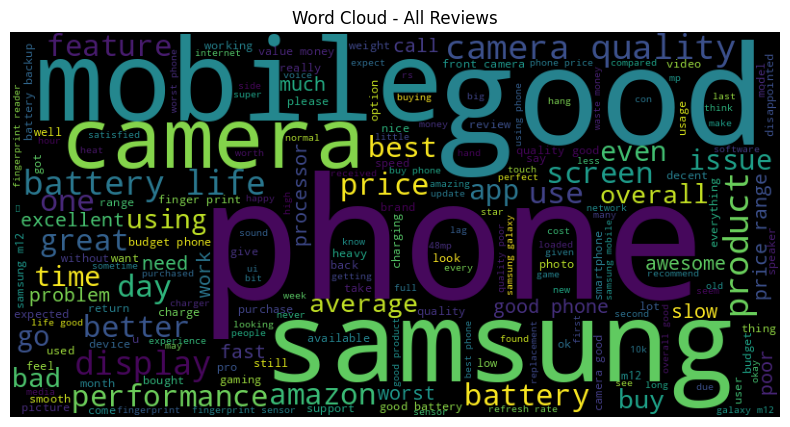

In [17]:
# WordCloud (All Reviews)
wordcloud = WordCloud(width=800, height=400).generate(" ".join(filtered_words))

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis('off')
plt.title("Word Cloud - All Reviews")
plt.show()

In [18]:
# Top Words in Negative Reviews
negative_text = " ".join(df[df['sentiment'] == "Negative"]['review'])

neg_words = re.findall(r'\w+', negative_text.lower())
neg_common = Counter(neg_words).most_common(15)

print("Top Negative Words:")
print(neg_common)

Top Negative Words:
[('is', 948), ('the', 732), ('phone', 642), ('not', 636), ('i', 599), ('and', 591), ('this', 572), ('to', 537), ('it', 474), ('in', 388), ('samsung', 377), ('a', 340), ('for', 332), ('of', 330), ('t', 319)]


In [19]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = text.split()
    text = [word for word in text if word not in stop_words]
    return " ".join(text)

# If you already combined title + body
df['review_text'] = df['title'] + " " + df['body']

# Now create clean_text
df['clean_text'] = df['review_text'].apply(clean_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

from sklearn.model_selection import train_test_split

X = tfidf.fit_transform(df['clean_text'])
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [21]:
from imblearn.over_sampling import SMOTE

# Convert sparse → dense (needed for SMOTE)
X_train_dense = X_train.toarray()

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_dense, y_train)

In [22]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=200)

lr_model.fit(X_train_resampled, y_train_resampled)

LogisticRegression(max_iter=200)

In [23]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

# NOTE: NB works better without SMOTE → use original data
nb_model.fit(X_train, y_train)

MultinomialNB()

In [24]:
# Logistic Regression (SMOTE)
y_pred_lr = lr_model.predict(X_test.toarray())

# Naive Bayes (No SMOTE)
y_pred_nb = nb_model.predict(X_test)

In [25]:
from sklearn.metrics import accuracy_score

print("LR Accuracy:", accuracy_score(y_test, y_pred_lr))
print("NB Accuracy:", accuracy_score(y_test, y_pred_nb))

LR Accuracy: 0.75
NB Accuracy: 0.7326388888888888


In [26]:
from sklearn.metrics import classification_report

print("Logistic Regression Report:\n", classification_report(y_test, y_pred_lr))
print("Naive Bayes Report:\n", classification_report(y_test, y_pred_nb))

Logistic Regression Report:
               precision    recall  f1-score   support

    Negative       0.78      0.81      0.79       102
     Neutral       0.34      0.30      0.32        40
    Positive       0.83      0.83      0.83       146

    accuracy                           0.75       288
   macro avg       0.65      0.65      0.65       288
weighted avg       0.74      0.75      0.75       288

Naive Bayes Report:
               precision    recall  f1-score   support

    Negative       0.84      0.67      0.74       102
     Neutral       0.00      0.00      0.00        40
    Positive       0.69      0.98      0.81       146

    accuracy                           0.73       288
   macro avg       0.51      0.55      0.52       288
weighted avg       0.65      0.73      0.67       288



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


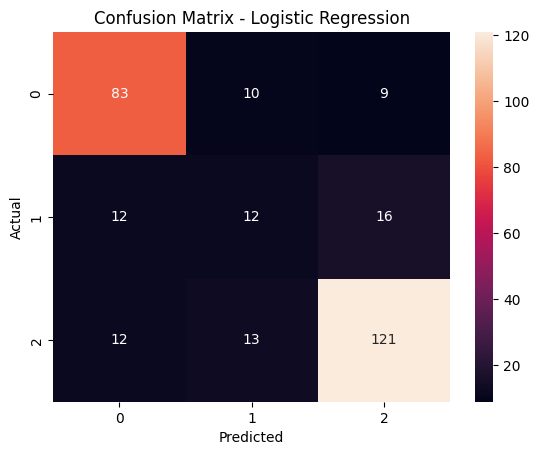

In [27]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [28]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = 5000
max_len = 100

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(df['clean_text'])

X_seq = tokenizer.texts_to_sequences(df['clean_text'])
X_pad = pad_sequences(X_seq, maxlen=max_len)

In [29]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(df['sentiment'])

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_pad, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

In [31]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding

model = Sequential()

model.add(Embedding(input_dim=max_words, output_dim=128, input_length=max_len))
model.add(LSTM(64))
model.add(Dense(32, activation='relu'))
model.add(Dense(3, activation='softmax'))  # 3 classes

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [32]:
model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - accuracy: 0.5182 - loss: 0.9976 - val_accuracy: 0.7083 - val_loss: 0.8801
Epoch 2/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.7595 - loss: 0.6862 - val_accuracy: 0.7361 - val_loss: 0.7316
Epoch 3/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy: 0.8273 - loss: 0.4399 - val_accuracy: 0.7431 - val_loss: 0.6648
Epoch 4/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - accuracy: 0.8585 - loss: 0.3176 - val_accuracy: 0.7326 - val_loss: 0.7434
Epoch 5/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - accuracy: 0.9427 - loss: 0.1812 - val_accuracy: 0.7535 - val_loss: 0.8150


In [33]:
loss, accuracy = model.evaluate(X_test, y_test)
print("LSTM Accuracy:", accuracy)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7535 - loss: 0.8150
LSTM Accuracy: 0.7534722089767456


In [34]:
import pickle

# model save
pickle.dump(lr_model, open("model.pkl", "wb"))

# vectorizer save
pickle.dump(tfidf, open("vectorizer.pkl", "wb"))

In [35]:
from google.colab import files

files.download("model.pkl")
files.download("vectorizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>